0.Setup - import the tools we need

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1. load the data and take a first look

In [103]:

df = pd.read_csv("/content/sample_data/laptopData.csv")
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


2. data set size

In [104]:
df.shape

(1303, 12)

3. colomns names

In [105]:
df.columns

Index(['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution',
       'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='object')

4. data tybes

In [106]:
df.dtypes

,0
Unnamed: 0,float64
Company,object
TypeName,object
Inches,object
ScreenResolution,object
Cpu,object
Ram,object
Memory,object
Gpu,object
OpSys,object


5. display the firs five rows

6. data set information

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1273 non-null   float64
 1   Company           1273 non-null   object 
 2   TypeName          1273 non-null   object 
 3   Inches            1273 non-null   object 
 4   ScreenResolution  1273 non-null   object 
 5   Cpu               1273 non-null   object 
 6   Ram               1273 non-null   object 
 7   Memory            1273 non-null   object 
 8   Gpu               1273 non-null   object 
 9   OpSys             1273 non-null   object 
 10  Weight            1273 non-null   object 
 11  Price             1273 non-null   float64
dtypes: float64(2), object(10)
memory usage: 122.3+ KB


7.describe data

In [108]:
# .describe() gives quick statistics for the NUMBER columns:
df.describe()

,Unnamed: 0,Price
count,1273.000000,1273.000000
mean,652.674784,59955.814073
std,376.493027,37332.251005
min,0.000000,9270.720000
25%,327.000000,31914.720000
50%,652.000000,52161.120000
75%,980.000000,79333.387200
max,1302.000000,324954.720000


8.missing values

In [109]:
# Count how many values are missing in each column, sorted from most to least
df.isnull().sum().sort_values(ascending=False)

,0
Unnamed: 0,30
Company,30
TypeName,30
Inches,30
ScreenResolution,30
Cpu,30
Ram,30
Memory,30
Gpu,30
OpSys,30


In [110]:
df.isna().sum()

,0
Unnamed: 0,30
Company,30
TypeName,30
Inches,30
ScreenResolution,30
Cpu,30
Ram,30
Memory,30
Gpu,30
OpSys,30


it shows there is 30 missing values

9. describe incloud object

In [111]:
df.describe(include="object")

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
count,1273,1273,1273,1273,1273,1273,1273,1273,1273,1273
unique,19,6,25,40,118,10,40,110,9,189
top,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.2kg
freq,290,710,640,495,183,601,401,271,1047,111


EDA visulalization

<Axes: title={'center': 'Number of Laptops by Company'}, xlabel='Company'>

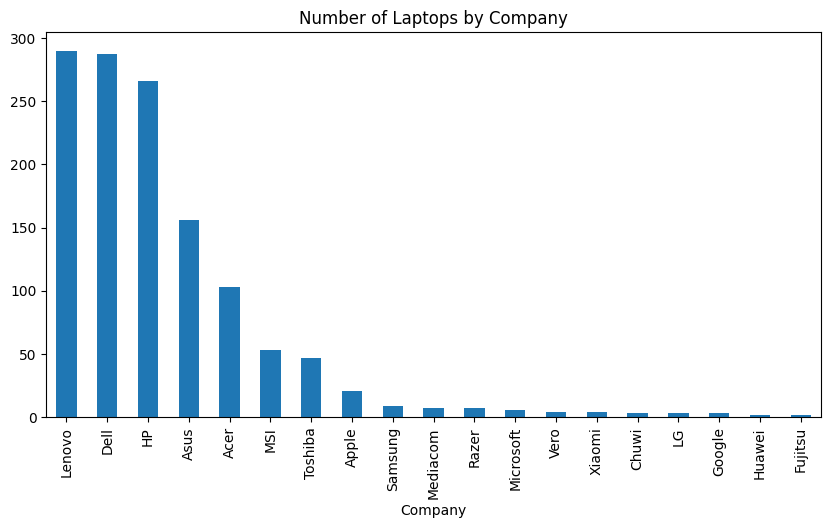

In [112]:
df["Company"].value_counts().plot(kind="bar", figsize=(10, 5), title="Number of Laptops by Company")

11. price Distribution |
helps me understand the common price range and check if there are very high or unusual prices.

<Axes: title={'center': 'Distribution of Laptop Prices'}, ylabel='Frequency'>

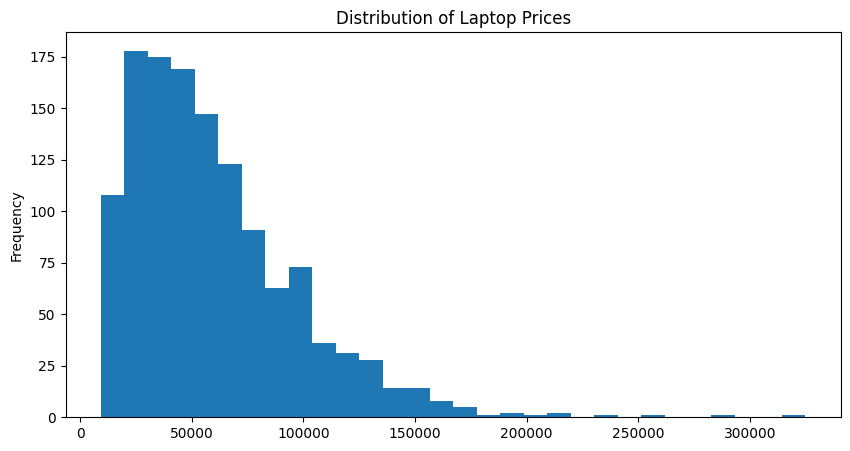

In [113]:
df["Price"].plot(kind="hist", bins=30, figsize=(10, 5), title="Distribution of Laptop Prices")

right-skewed | Most laptops are in the lower and middle price ranges, while a few laptops have very high prices.

Laptop Type

<Axes: title={'center': 'Number of Laptops by Type'}, xlabel='TypeName'>

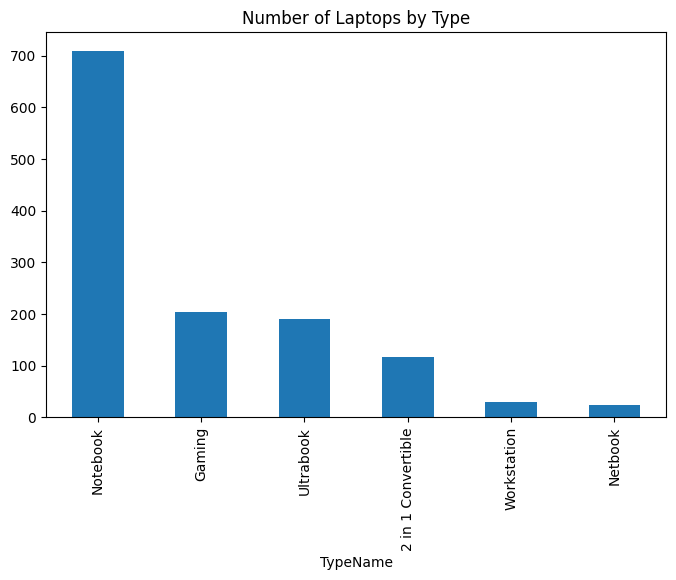

In [114]:
df["TypeName"].value_counts().plot(kind="bar", figsize=(8, 5), title="Number of Laptops by Type")

The chart shows that Notebook is the most common laptop type in the dataset


This step : we check if the dataset contains duplicated rows

In [115]:
df.duplicated().sum()

np.int64(29)

Dataset contains duplicated rows

The column Unnamed: 0 appears to be an old index column

In [116]:
df = df.drop("Unnamed: 0", axis=1)

In [117]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


we check if the missing values come from rows that are completely empty.

In [118]:
df.isna().all(axis=1).sum()

np.int64(30)

dataset contains 30 fully empty rows

In [119]:
df = df.dropna(how="all")

In [120]:
df.shape

(1273, 11)

check and remove duplicated rows because repeated records may affect the model performance

In [121]:
df.duplicated().sum()

np.int64(29)

In [122]:
df = df.drop_duplicates()
df.shape

(1244, 11)

we will remove the GB text and convert the column to numeric.

In [123]:
df["Ram"] = df["Ram"].str.replace("GB", "").astype(int)

 we remove the kg text and convert the column to numeric

In [124]:
df["Weight"] = df["Weight"].str.replace("kg", "")
df["Weight"] = pd.to_numeric(df["Weight"], errors="coerce")

I replace these invalid values with missing values, then convert the column to numeric.

In [125]:
df["Weight"].isna().sum()

np.int64(1)

In [126]:
df["Weight"] = df["Weight"].fillna(df["Weight"].median())

In [127]:
df["Weight"].isna().sum()

np.int64(0)

 using the median because the median is less affected by extreme values.

In [128]:
df.dtypes

,0
Company,object
TypeName,object
Inches,object
ScreenResolution,object
Cpu,object
Ram,int64
Memory,object
Gpu,object
OpSys,object
Weight,float64


 convert Inches from text to a numeric column.

In [129]:
df["Inches"] = pd.to_numeric(df["Inches"], errors="coerce")

In [130]:
df["Inches"].isna().sum()

np.int64(1)

we check the most common values to understand how storage information is written in the dataset

In [131]:
df["Memory"].value_counts().head(10)

,count
Memory,
256GB SSD,401
1TB HDD,209
500GB HDD,121
512GB SSD,112
128GB SSD + 1TB HDD,92
128GB SSD,72
256GB SSD + 1TB HDD,71
32GB Flash Storage,35
2TB HDD,16


we create a new numeric column called Memory_GB to represent the total storage size in GB.

In [132]:
def convert_memory_to_gb(value):
    value = str(value)
    parts = value.split("+")
    total = 0

    for part in parts:
        part = part.strip()
        size = part.split()[0]

        if "TB" in size:
            number = float(size.replace("TB", ""))
            total = total + number * 1024

        elif "GB" in size:
            number = float(size.replace("GB", ""))
            total = total + number

    return total

df["Memory_GB"] = df["Memory"].apply(convert_memory_to_gb)

In [133]:
df[["Memory", "Memory_GB"]].head(10)

,Memory,Memory_GB
0,128GB SSD,128.0
1,128GB Flash Storage,128.0
2,256GB SSD,256.0
3,512GB SSD,512.0
4,256GB SSD,256.0
5,500GB HDD,500.0
6,256GB Flash Storage,256.0
7,256GB Flash Storage,256.0
8,512GB SSD,512.0
9,256GB SSD,256.0


In [134]:
df.dtypes

,0
Company,object
TypeName,object
Inches,float64
ScreenResolution,object
Cpu,object
Ram,int64
Memory,object
Gpu,object
OpSys,object
Weight,float64


 the original Memory column is no longer needed because it contains text values.

In [135]:
df = df.drop("Memory", axis=1)

In [136]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Gpu,OpSys,Weight,Price,Memory_GB
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,128.0
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,128.0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,Intel HD Graphics 620,No OS,1.86,30636.0000,256.0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,512.0
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,256.0


we check for possible outliers in the Price column using a boxplot. Since Price is the target column extreme prices may affect the model performance.

<Axes: title={'center': 'Boxplot of Laptop Prices'}>

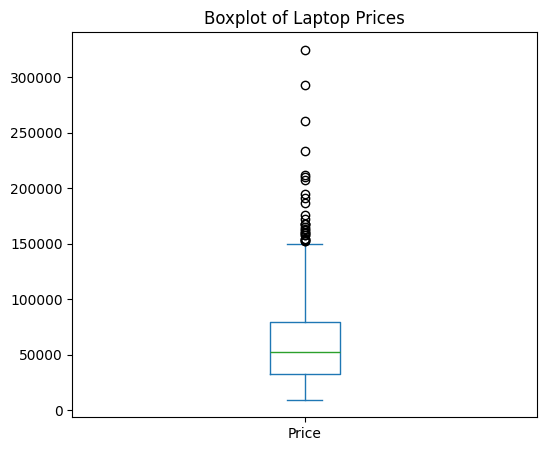

In [137]:
df["Price"].plot(kind="box", figsize=(6, 5), title="Boxplot of Laptop Prices")

Counting Price Outliers Using IQR

In [138]:
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df["Price"] < lower_limit) | (df["Price"] > upper_limit)]

len(outliers)

28

Removing Price Outliers

In [139]:
df = df[(df["Price"] >= lower_limit) & (df["Price"] <= upper_limit)]

In [140]:
df.shape

(1216, 11)

   now contains 1216 rows and 11 columns.

target variable is Price because I want to predict laptop prices.

In [141]:
X = df.drop("Price", axis=1)
y = df["Price"]

we use one-hot encoding to convert categorical columns into numeric columns.

In [142]:
X = pd.get_dummies(X, drop_first=True)

we check the shape of the feature data to see how many columns were created.

In [143]:
df["Cpu_Brand"] = df["Cpu"].str.split().str[0]

df["Gpu_Brand"] = df["Gpu"].str.split().str[0]

df = df.drop(["Cpu", "Gpu"], axis=1)

X = df.drop("Price", axis=1)
y = df["Price"]

X = pd.get_dummies(X, drop_first=True)



In [144]:
X.shape

(1216, 79)

This makes the dataset simpler and easier for the model to learn from.

Scaling before PCA helps some machine learning models perform better.

In [145]:
X.isna().sum()[X.isna().sum() > 0]

,0
Inches,1


In [146]:
df["Inches"] = df["Inches"].fillna(df["Inches"].median())

In [147]:
X = df.drop("Price", axis=1)
y = df["Price"]
X = pd.get_dummies(X, drop_first=True)
X.isna().sum().sum()

np.int64(0)

we used median to solve this proplem

In [148]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
X_train_pca.shape, X_test_pca.shape

((972, 56), (244, 56))

After PCA number of features was reduced from 79 to 56 components.

Explained Variance

In [149]:
pca.explained_variance_ratio_.sum()

np.float64(0.9541000476521491)

PCA kept about 95% of the variance in the data

PCA Explained Variance shows how much information was kept after applying PCA.

In [150]:
pca.explained_variance_ratio_.sum()

np.float64(0.9541000476521491)

modling 1 : linear regression

In [151]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X_train_pca, y_train)
y_pred_linear = linear_model.predict(X_test_pca)

evaluating the model using regression metrics: MAE,MSE,RMSE,R2 score.

In [152]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(y_test, y_pred_linear)
mse = mean_squared_error(y_test, y_pred_linear)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_linear)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 13663.471981297118
MSE: 332675705.98162156
RMSE: 18239.399825148346
R2 Score: 0.6912941127982708


R2 score : 0.69 which means it explains about 69% of the price variation

Modeling 2 Random Forest Regressor
Random Forest Regressor the second model because it can capture non-linear relationships between laptop specifications and price

In [153]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

Evaluating Random Forest Regressor

In [154]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

MAE: 10964.335728262382
MSE: 231871793.22257495
RMSE: 15227.337036480638
R2 Score: 0.7848349417862652


Random Forest Regressor performed higher R2 score and lower MAE and RMSE values
 This means Random Forest made more accurate predictions and explained more of the price variation
 Therefore Random Forest is the better model for this dataset.

Model Comparison

In [155]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, mae_rf],
    "MSE": [mse, mse_rf],
    "RMSE": [rmse, rmse_rf],
    "R2 Score": [r2, r2_rf]
})
results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,13663.471981,3.326757e+08,18239.399825,0.691294
1,Random Forest,10964.335728,2.318718e+08,15227.337036,0.784835


Actual vs Predicted Prices

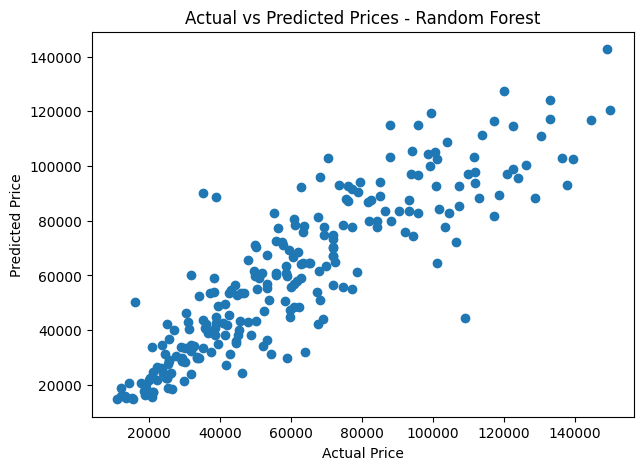

In [156]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices - Random Forest")
plt.show()

it shows that many predicted prices are close to the actual prices
but some points are still far away
This means the model performs reasonably well but it still makes errors for some laptops especially those with unusual prices or specifications.

Conclusion :
prediction of laptop prices using machine learning
First I cleaned the dataset by removing empty rows duplicated rows unnecessary columns and outliers. I also converted columns like Ram Weight Inches and Memory into numeric values.
After that I prepared the data by encoding text columns and scaling the features. Then I used PCA to reduce the number of features from 79 to 56 while keeping most of the important information.
then training two models Linear Regression and Random Forest Regressor.
Random Forest performed better than Linear Regression It had a higher R2 score and lower error values. This means Random Forest predicted laptop prices more accurately.
